# CEDAR Benchmark: Scaling vs CDNOTS+

How do the two discovery algorithms compare as dimensionality grows?

| Algorithm | Type | CI tests | Strength |
|-----------|------|----------|----------|
| **CDNOTS+** | Constraint-based (MCI) | O(d^k) — exponential in conditioning depth | High recall, MCI conditioning reduces FPs vs CDNOTS |
| **CEDAR** | Pairwise minimum-lag | O(d²) — two tests per pair | Fast, precise, scales well |

Benchmark: sparse mixed linear/nonlinear SCP, T=300, max_lag=2, 2 seeds, CPU only.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import time
from itertools import product as iproduct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from causalts.synthetic_data.synthetic_datasets import SCPGraphGenerator
from causalts.ci_tests import PartialCorr
from causalts import run_cdnots_plus
from causalts.cedar import run_cedar
from causalts.utils.helpers import precision_recall_3d, shd_3d
import causalts.plotting as tp

def eval_graph(est, gt):
    """Evaluate estimated vs ground-truth graph.

    Strips self-loops from both graphs (SCP GT has none;
    """
    gt = gt.copy()
    est = est.copy()
    for lag in range(gt.shape[2]):
        np.fill_diagonal(gt[:, :, lag], 0)
    d = gt.shape[0]
    if est.shape[2] < gt.shape[2]:
        est = np.concatenate([est, np.zeros((*est.shape[:2], gt.shape[2]-est.shape[2]))], 2)
    elif est.shape[2] > gt.shape[2]:
        est = est[:, :, :gt.shape[2]]
    est = est[:d, :d, :]
    for lag in range(est.shape[2]):
        np.fill_diagonal(est[:, :, lag], 0)
    prec, rec = precision_recall_3d(gt, est)
    f1  = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0.0
    shd = shd_3d(gt, est)
    return prec, rec, f1, shd, int(est.astype(bool).sum())


## Algorithms

- **CDNOTS+** — `run_cdnots_plus(df, ci, num_lags=2, alpha=0.01)` with `PartialCorr`.
  PCMCI+-style two-phase skeleton: Phase 1 discovers a parent superset per variable,
  Phase 2 MCI-retests each edge conditioning only on those parents — fewer FPs than CDNOTS.
- **CEDAR** — `run_cedar(df, ci, max_lag=2)` with `PartialCorr`.
  Pairwise minimum-lag; O(d²) CI tests; precise at any d.

In [2]:
def run_one(d, T=300, seed=42):
    """Run both algorithms on one random sparse SCP dataset."""
    gen = SCPGraphGenerator(n_vars=d, max_lag=2, density='sparse',
                            dependency_funcs=('lin','lin','nl1','nl2'))
    res = gen.sample(seed=seed, T=T, n_links=None, max_tries=10000)
    df, gt = res['df'], res['ground_truth']
    ci = PartialCorr(df.values)

    results = {}

    t0 = time.time()
    r = run_cdnots_plus(df, ci, num_lags=2, alpha=0.01)
    results['CDNOTS+'] = (*eval_graph(r.cg_tig[:d,:d,:], gt), round(time.time()-t0, 2))

    t0 = time.time()
    r = run_cedar(df, ci, alpha_cond1=0.01, alpha_cond2=0.01, max_lag=2, lag_method='partial_dcor')
    results['CEDAR'] = (*eval_graph(r.cg_tig, gt), round(time.time()-t0, 2))

    return {'results': results, 'gt': gt, 'df': df, 'var_names': list(df.columns)}


## Single Dataset Comparison (d=20)

Algo         Prec    Rec     F1   SHD  Edges    Time
----------------------------------------------------
CDNOTS+     0.905  0.864  0.884     5     21    0.41s
CEDAR       0.818  0.818  0.818     8     22    0.13s


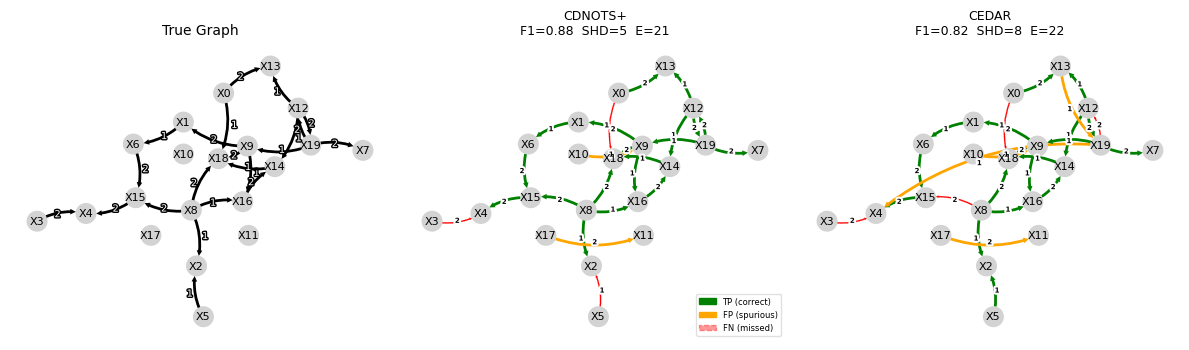

In [3]:
out20 = run_one(d=20, T=300, seed=42)
gt20, df20, vn20 = out20['gt'], out20['df'], out20['var_names']

print(f"{'Algo':<10} {'Prec':>6} {'Rec':>6} {'F1':>6} {'SHD':>5} {'Edges':>6} {'Time':>7}")
print('-' * 52)
for algo, vals in out20['results'].items():
    p, r, f, s, e, t = vals
    print(f"{algo:<10} {p:6.3f} {r:6.3f} {f:6.3f} {s:5d} {e:6d} {t:7.2f}s")

# Re-run with same alpha=0.01 used in the benchmark for consistent visualization
ci20 = PartialCorr(df20.values)
r_cdnots_plus = run_cdnots_plus(df20, ci20, num_lags=2, alpha=0.01)
r_cedar        = run_cedar(df20, ci20, alpha_cond1=0.01, alpha_cond2=0.01, max_lag=2)

d20 = df20.shape[1]
gt20c = gt20.copy()
for lag in range(gt20c.shape[2]):
    np.fill_diagonal(gt20c[:, :, lag], 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

_, _, pos = tp.plot_graph(
    gt20c, var_names=vn20, node_layout="neato", node_label_size=8,
    arrow_linewidth=2, link_label_fontsize=7, node_size=0.12,
    show_colorbar=False, fig_ax=(fig, axes[0]), return_pos=True,
)
axes[0].set_title('True Graph', fontsize=10)

for ax, algo, graph in zip(axes[1:],
        ['CDNOTS+', 'CEDAR'],
        [r_cdnots_plus.cg_tig[:d20,:d20,:], r_cedar.cg_tig]):
    p, r, f, s, e, _ = out20['results'][algo]
    tp.compare_graphs(
        gt20c, graph, var_names=vn20, node_pos=pos,
        arrow_linewidth=2, link_label_fontsize=5, node_size=0.12,
        show_legend=(algo == 'CDNOTS+'), legend_loc='lower right',
        legend_fontsize=6, legend_framealpha=0.6, node_label_size=8,
        fig_ax=(fig, ax),
    )
    ax.set_title(f'{algo}\nF1={f:.2f}  SHD={s}  E={e}', fontsize=9)

plt.tight_layout()
plt.show()


## Scaling Study: d = 5 to 40 (T=300, 4 seeds)

In [4]:
D_VALUES = [5, 10, 15, 20, 25, 30, 35, 40]
SEEDS    = [42, 56, 45, 123]
ALGOS    = ['CDNOTS+', 'CEDAR']

rows = []
for d, seed in tqdm(list(iproduct(D_VALUES, SEEDS)), desc='Benchmarking', unit='run'):
    out = run_one(d=d, T=300, seed=seed)
    for algo in ALGOS:
        p, r, f, s, e, t = out['results'][algo]
        rows.append({'d': d, 'seed': seed, 'algo': algo,
                     'Prec': p, 'Rec': r, 'F1': f,
                     'SHD': s, 'Edges': e, 'Time': t})

df_bench = pd.DataFrame(rows)
summary  = df_bench.groupby(['d','algo'])[['F1','Prec','Rec','SHD','Time']].mean().round(3)
print(summary.to_string())

Benchmarking:   0%|          | 0/32 [00:00<?, ?run/s]

               F1   Prec    Rec    SHD   Time
d  algo                                      
5  CDNOTS+  0.922  0.950  0.917   0.50  0.032
   CEDAR    0.950  1.000  0.917   0.25  0.010
10 CDNOTS+  0.716  0.833  0.634   5.50  0.132
   CEDAR    0.824  0.975  0.732   3.25  0.032
15 CDNOTS+  0.784  0.914  0.696   6.75  0.185
   CEDAR    0.774  0.912  0.682   7.00  0.070
20 CDNOTS+  0.778  0.833  0.731   9.25  0.465
   CEDAR    0.809  0.895  0.742   7.75  0.130
25 CDNOTS+  0.743  0.771  0.727  13.50  0.805
   CEDAR    0.788  0.886  0.710  10.50  0.188
30 CDNOTS+  0.693  0.699  0.689  19.00  1.512
   CEDAR    0.760  0.837  0.697  13.75  0.295
35 CDNOTS+  0.732  0.736  0.731  18.25  1.600
   CEDAR    0.800  0.867  0.744  12.75  0.368
40 CDNOTS+  0.693  0.656  0.735  24.75  2.638
   CEDAR    0.772  0.841  0.714  15.75  0.478


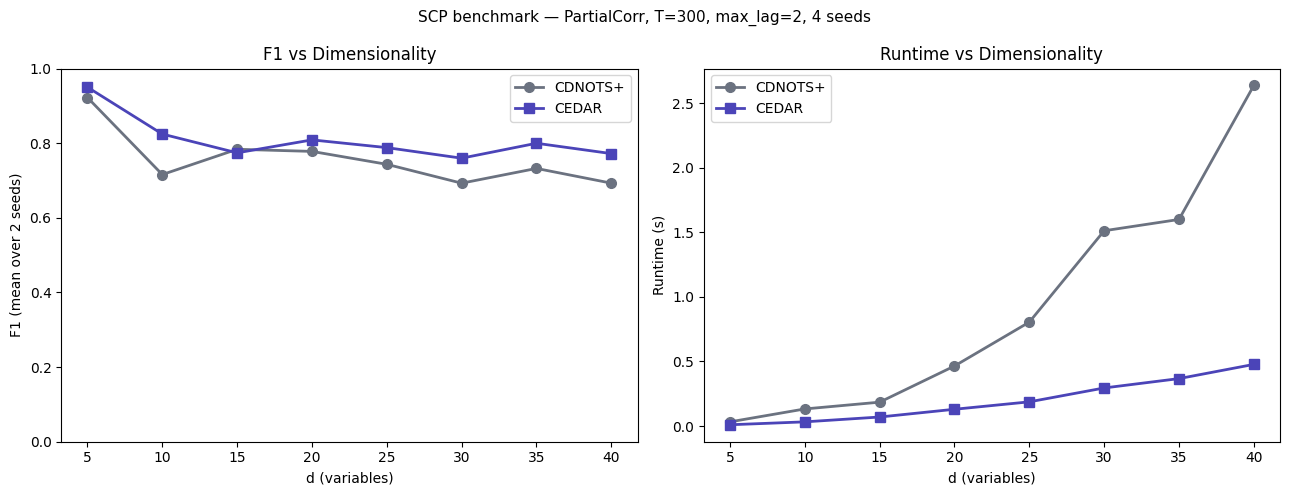

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors  = {'CDNOTS+': '#6b7280', 'CEDAR': '#4B44B8'}
markers = {'CDNOTS+': 'o',       'CEDAR': 's'}

for algo in ALGOS:
    sub = df_bench[df_bench['algo'] == algo].groupby('d').mean(numeric_only=True)
    axes[0].plot(sub.index, sub['F1'], marker=markers[algo], color=colors[algo],
                 label=algo, linewidth=2, markersize=7)
    axes[1].plot(sub.index, sub['Time'], marker=markers[algo], color=colors[algo],
                 label=algo, linewidth=2, markersize=7)

axes[0].set_xlabel('d (variables)'); axes[0].set_ylabel('F1 (mean over 2 seeds)')
axes[0].set_title('F1 vs Dimensionality'); axes[0].legend(); axes[0].set_ylim(0, 1)
axes[0].set_xticks(D_VALUES)

axes[1].set_xlabel('d (variables)'); axes[1].set_ylabel('Runtime (s)')
axes[1].set_title('Runtime vs Dimensionality'); axes[1].legend()
axes[1].set_xticks(D_VALUES)

plt.suptitle('SCP benchmark — PartialCorr, T=300, max_lag=2, 4 seeds', fontsize=11)
plt.tight_layout()
plt.show()

## Key Takeaways

- **CEDAR maintains high F1 ** with the lowest and most stable runtime —
  its O(d²) complexity means lag-selection cost grows linearly with pairs, not
  combinatorially with conditioning-set size.
- **CDNOTS+** uses MCI conditioning (Phase 2 re-tests each edge only against its parent
  superset), which reduces the false-positive rate compared to vanilla CDNOTS — but
  conditioning sets still grow with d, so F1 degrades with increase in d.
- **For large d**, `CEDAR` with `PartialCorr` is the recommended default: high F1 and
  sub-second runtime. Switch to `CDNOTS+` when a data is not autoregressive.